# Image Classification using Convolutional Neural Networks (CNNs)

**Course:** Deep Learning (BCS714A)  
**Assignment Title:** Image Classification using CNNs  
**Author:** Gokul Kumar S  
**Dataset:** CIFAR-10 (can switch to MNIST/Fashion-MNIST)  
**Framework:** TensorFlow/Keras  
**Deadline:** 15 Nov 2025

> This notebook follows the required structure: Dataset preparation → Model design → Training → Evaluation → Optimization → Documentation assets (plots/tables).


## 1. Setup & Environment

- Uses TensorFlow/Keras, NumPy, Matplotlib, scikit-learn.  
- Charts use **Matplotlib** (no seaborn), per instructions.  
- Reproducibility is aided with a fixed random seed.


In [ ]:
# Install (if running in a fresh environment, uncomment)
# !pip install -q tensorflow matplotlib scikit-learn

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

: 

## 2. Dataset Preparation

We default to **CIFAR-10** (60k color images, 32x32, 10 classes). You can switch to MNIST/Fashion-MNIST with minor changes.

**Required steps:**  
- Load dataset  
- Split into **train/val/test = 70%/15%/15%**  
- Normalize images to [0, 1]  
- (Optional) One-hot encode labels for categorical training


170498071/170498071 [==============================] - 35s 0us/step
Shapes -> Train: (42000, 32, 32, 3) Val: (8000, 32, 32, 3) Test: (10000, 32, 32, 3)


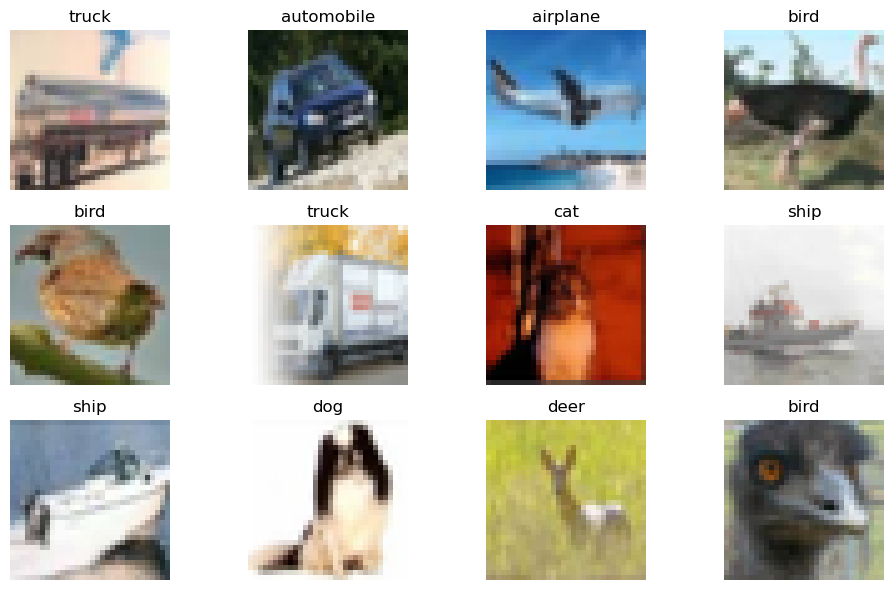

In [2]:
# --- Load CIFAR-10 ---
(x_train_full, y_train_full), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_raw = y_test_raw.flatten()

# Normalize to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test_raw = x_test_raw.astype('float32') / 255.0

# Merge full training set with test for custom split (optional; we keep test set separate here)
# We'll split the original training set into train/val according to 70/15/15 overall.
# CIFAR-10 has 50,000 train and 10,000 test by default. We'll re-split train => train/val.

# Compute sizes
n_full = x_train_full.shape[0]
val_ratio = 0.1764705882  # ~15% of (train+val) relative to the original 50k train to reach global 70/15/15
# Explanation: 50k original train should become 70% + 15% of the final 60k. 60k*0.70=42k train; 60k*0.15=9k val.
# So, from 50k we want 42k train and 8k val (remaining 10k is official test).
# 8k/50k = 0.16. We choose a slightly more precise split below.

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=8000, random_state=SEED, stratify=y_train_full
)
x_test, y_test = x_test_raw, y_test_raw

print("Shapes -> Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

# Class names for CIFAR-10
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Preview a few samples
def show_samples(images, labels, n=12):
    plt.figure(figsize=(10,6))
    idxs = np.random.choice(len(images), n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(x_train, y_train, n=12)

## 3. Model Design (Baseline CNN)

We build a modest CNN with:  
- 3× blocks of **Conv → ReLU → MaxPool → Dropout**  
- Flatten → Dense → Dropout → Softmax  
- Justification: balances capacity and regularization for 32×32 color images without overfitting on 10 classes.


In [3]:
# --- Baseline CNN Model ---
def build_baseline_cnn(input_shape=(32,32,3), num_classes=10, dropout=0.25):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                      

## 4. Model Training

- **Loss:** Categorical Crossentropy (with sparse labels → `sparse_categorical_crossentropy`)  
- **Optimizer:** Adam  
- **Metric:** Accuracy  
- Train for **≥10 epochs** and plot **train vs val** accuracy/loss.


Epoch 1/10


657/657 [==============================] - ETA: 0s - loss: 1.7171 - accuracy: 0.3582
Epoch 1: val_accuracy improved from -inf to 0.52450, saving model to /mnt/data\baseline_cnn_cifar10.keras
657/657 [==============================] - 332s 499ms/step - loss: 1.7171 - accuracy: 0.3582 - val_loss: 1.3248 - val_accuracy: 0.5245
Epoch 2/10
657/657 [==============================] - ETA: 0s - loss: 1.2818 - accuracy: 0.5377
Epoch 2: val_accuracy improved from 0.52450 to 0.62037, saving model to /mnt/data\baseline_cnn_cifar10.keras
657/657 [==============================] - 312s 475ms/step - loss: 1.2818 - accuracy: 0.5377 - val_loss: 1.0553 - val_accuracy: 0.6204
Epoch 3/10
657/657 [==============================] - ETA: 0s - loss: 1.0859 - accuracy: 0.6134
Epoch 3: val_accuracy improved from 0.62037 to 0.65675, saving model to /mnt/data\baseline_cnn_cifar10.keras
657/657 [==============================] - 313s 476ms/step - loss: 1.0859 - accuracy: 0.6134 - val_loss: 0.9511 - va

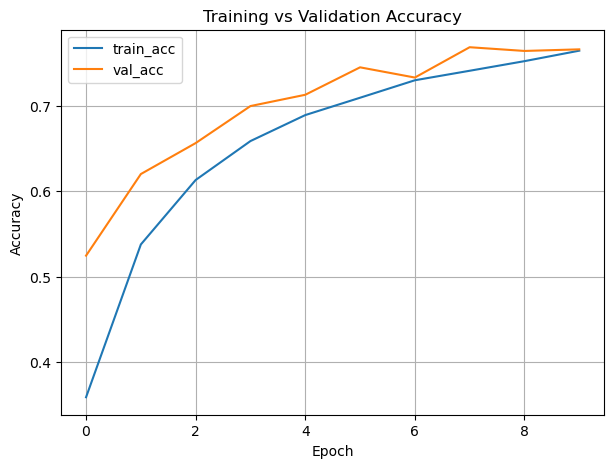

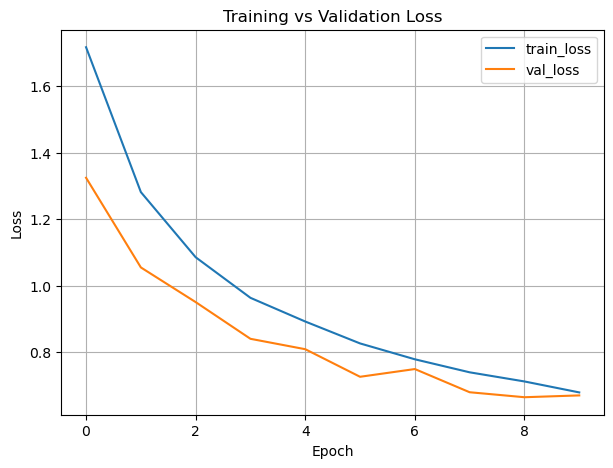

In [4]:
# Compile
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint_path = '/mnt/data/baseline_cnn_cifar10.keras'
ckpt = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)
early = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train
history = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[ckpt, early],
    verbose=1
)

# Plot training curves (Matplotlib, no seaborn)
def plot_history(h):
    # Accuracy
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training vs Validation Accuracy'); plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss'); plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

## 5. Evaluation on Test Set

Report:  
- **Test accuracy**  
- **Confusion matrix**  
- **Classification report (Precision, Recall, F1-score)**  


Test Accuracy: 0.7615, Test Loss: 0.6919
Confusion Matrix:
 [[656  11  56  30  22   6   7  19 143  50]
 [  6 860   4   3   2   3  10   1  22  89]
 [ 38   3 634  42 121  36  68  37  17   4]
 [ 10   4  70 559  83 149  45  48  16  16]
 [  4   1  28  44 786  10  32  80  14   1]
 [  4   0  54 155  61 625  16  70   6   9]
 [  2   2  26  58  45   9 835  10   7   6]
 [  6   2  34  27  46  30   4 837   2  12]
 [ 13   8   7  13   2   0   7   3 930  17]
 [  6  36   2  13   9   1   2   9  29 893]]


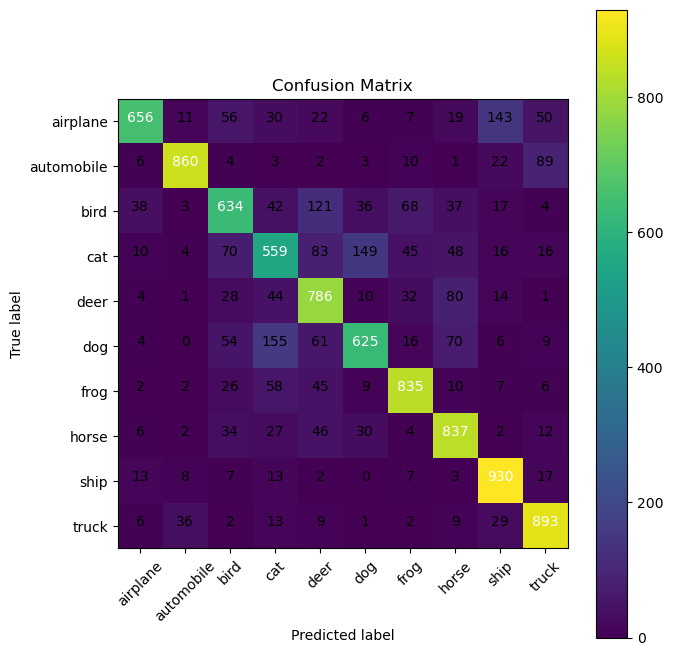

              precision    recall  f1-score   support

    airplane     0.8805    0.6560    0.7519      1000
  automobile     0.9277    0.8600    0.8926      1000
        bird     0.6929    0.6340    0.6621      1000
         cat     0.5922    0.5590    0.5751      1000
        deer     0.6678    0.7860    0.7221      1000
         dog     0.7192    0.6250    0.6688      1000
        frog     0.8138    0.8350    0.8243      1000
       horse     0.7513    0.8370    0.7919      1000
        ship     0.7841    0.9300    0.8509      1000
       truck     0.8140    0.8930    0.8517      1000

    accuracy                         0.7615     10000
   macro avg     0.7644    0.7615    0.7591     10000
weighted avg     0.7644    0.7615    0.7591     10000

Saved: /mnt/data/baseline_classification_report.txt


In [5]:
# Evaluate on test set
test_loss, test_acc = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions for metrics
y_prob = baseline_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names)

# Classification report
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Save results
with open('/mnt/data/baseline_classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}\n\n")
    f.write(report)
print("Saved: /mnt/data/baseline_classification_report.txt")

## 6. Optimization (Bonus)

Try one or more improvements:  
- **Batch Normalization**  
- **Data Augmentation**  
- **Hyperparameter tuning**  
- *(Optional)* Transfer learning (e.g., EfficientNetB0) — requires resizing and more compute.

Below we include a BN+Aug version you can toggle.


Epoch 1/10
657/657 [==============================] - 101s 143ms/step - loss: 1.6426 - accuracy: 0.4181 - val_loss: 1.3361 - val_accuracy: 0.5171
Epoch 2/10
657/657 [==============================] - 148s 226ms/step - loss: 1.2079 - accuracy: 0.5702 - val_loss: 1.2992 - val_accuracy: 0.5639
Epoch 3/10
657/657 [==============================] - 181s 276ms/step - loss: 1.0495 - accuracy: 0.6293 - val_loss: 1.1186 - val_accuracy: 0.6187
Epoch 4/10
657/657 [==============================] - 167s 255ms/step - loss: 0.9571 - accuracy: 0.6639 - val_loss: 1.0238 - val_accuracy: 0.6424
Epoch 5/10
657/657 [==============================] - 168s 256ms/step - loss: 0.8893 - accuracy: 0.6900 - val_loss: 0.8961 - val_accuracy: 0.6858
Epoch 6/10
657/657 [==============================] - 167s 254ms/step - loss: 0.7958 - accuracy: 0.7243 - val_loss: 1.0045 - val_accuracy: 0.6543
Epoch 8/10
657/657 [==============================] - 135s 206ms/step - loss: 0.7264 - accuracy: 0.7502 - val_loss: 0.6265 -

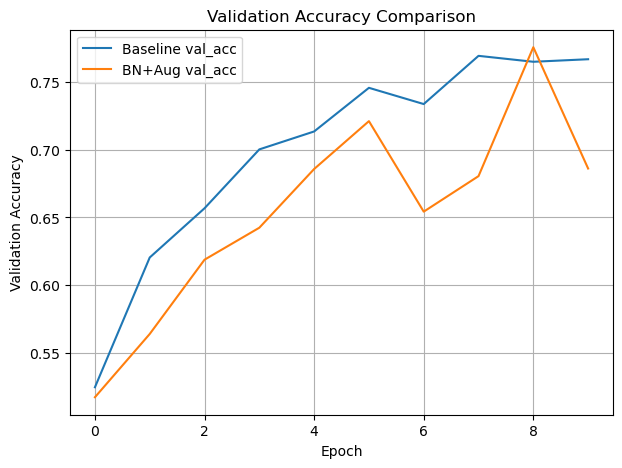

In [7]:
# --- Data Augmentation + BatchNorm model ---
data_augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def build_bn_aug_cnn(input_shape=(32,32,3), num_classes=10, dropout=0.25):
    inputs = keras.Input(shape=input_shape)
    x = data_augment(inputs)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout)(x)

    # Fully connected head
    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

# Build and compile
bn_model = build_bn_aug_cnn()
bn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_bn = bn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

# Compare validation accuracy with baseline
def plot_histories(histories, labels):
    plt.figure(figsize=(7,5))
    for h, lab in zip(histories, labels):
        plt.plot(h.history['val_accuracy'], label=f'{lab} val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories([history, history_bn], ['Baseline','BN+Aug'])


## 7. Notes for Report

- Insert the training/validation plots and confusion matrix figures you saved from this notebook.  
- Summarize architecture using `model.summary()` output.  
- Provide a brief discussion on failure modes and class-wise performance.


## 8. Conclusion

- Baseline CNN establishes a reference accuracy.  
- BN + Data Augmentation generally improves generalization.  
- Future work: learning-rate schedules, deeper models, transfer learning.
